In [1]:
## Gene Expression Prediction Using SVR

In [2]:
# Requirements

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
import shap
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from scipy.stats import shapiro
from scipy.stats import pearsonr
import gc
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from scipy.stats import zscore
import math
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import pearsonr
plt.rcParams['pdf.fonttype'] = 42

/Users/madisoncreach/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# read in the input dataframes

path = ('/Users/madisoncreach/Prediction_Project/Input_Datasets/NE_gene_expression.csv')
NE_exp = pd.read_csv(path, header=0)

path2 = ('/Users/madisoncreach/Prediction_Project/Input_Datasets/MI_gene_expression.csv')
MI_exp = pd.read_csv(path2, header=0)

In [4]:
# make sure Gene ID is set as index
MI_exp_index = MI_exp.set_index('Unnamed: 0')
MI_l2b = MI_exp_index.rename_axis('GeneID')

NE_exp_index = NE_exp.set_index('Unnamed: 0')
NE_l2b = NE_exp_index.rename_axis('GeneID')

In [5]:
# read in labels df

phenos = pd.read_csv('/Users/madisoncreach/Prediction_Project/Input_Datasets/full_phenos_reduced.csv', header=0)

In [6]:
# set the index as GeneID

full_phenos = phenos.set_index('GeneID')

In [7]:
## Do a plot of a specific gene expression vs flowering time

In [8]:
# subset the dataframes for the phenotype of interest 

pheno_ft = full_phenos["Anthesis1_L"]
ft_phenos_NE_l2b = NE_l2b.join(pheno_ft, how='inner')
ft_phenos_MI_l2b = MI_l2b.join(pheno_ft, how='inner')
ft_phenos_l2b_NE_MI = pd.concat([ft_phenos_NE_l2b, ft_phenos_MI_l2b], axis=0).dropna()

In [9]:
print(ft_phenos_l2b_NE_MI)

         Zm00001eb000010  Zm00001eb000020  Zm00001eb000060  Zm00001eb000070  \
GeneID                                                                        
2369            2.927385         0.677681         3.875023         0.364208   
4N506           3.215471         0.888903         3.583210         0.245840   
52220           3.145799         1.016918         3.930341         0.905503   
764             2.863144         0.965552         4.122003         0.368767   
793             3.122899         1.001382         3.655645         0.245840   
...                  ...              ...              ...              ...   
Fe              2.570366         1.031776         3.984384         2.060331   
R227            3.080749         0.788508         3.236801         0.917630   
Hi26            2.860777         0.777449         3.450509         0.454616   
CML_322         2.469534         1.697915         0.226697         0.168179   
CI_64           3.019283         0.610056         2.

In [10]:
# The two genes of interest are "Zm00001eb153190" and "Zm00001eb214750"

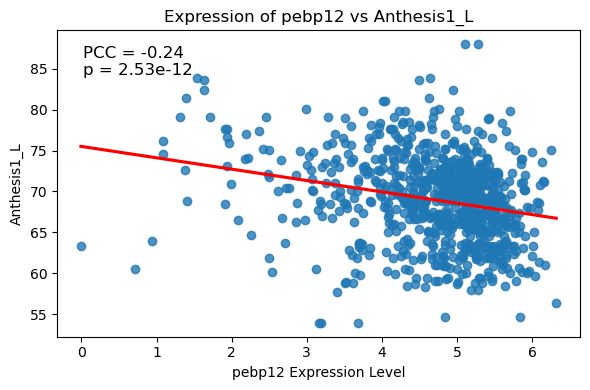

In [11]:
from scipy.stats import pearsonr

gene = "Zm00001eb153190"   
trait = "Anthesis1_L"          

x = ft_phenos_l2b_NE_MI[gene]
y = ft_phenos_l2b_NE_MI[trait]

pcc, pval = pearsonr(x, y)

plt.figure(figsize=(6, 4))
sns.regplot(x=x, y=y, line_kws={'color': 'red'}, ci=None)

# Annotate PCC and p-value on plot
plt.text(0.05, 0.95, f"PCC = {pcc:.2f}\np = {pval:.2e}", 
         transform=plt.gca().transAxes,
         verticalalignment='top', fontsize=12)

plt.xlabel(f"pebp12 Expression Level")
plt.ylabel(f"{trait}")
plt.title(f"Expression of pebp12 vs {trait}")
plt.tight_layout()
plt.show()

In [12]:
# subset the dataframes for the phenotype of interest 

pheno_MI_ft = full_phenos["AnthesisDAP"]
pheno_NE_ft = full_phenos["Anthesis_J"]
NE_ft_phenos_NE_l2b = NE_l2b.join(pheno_NE_ft, how='inner')
MI_ft_phenos_MI_l2b = MI_l2b.join(pheno_MI_ft, how='inner')

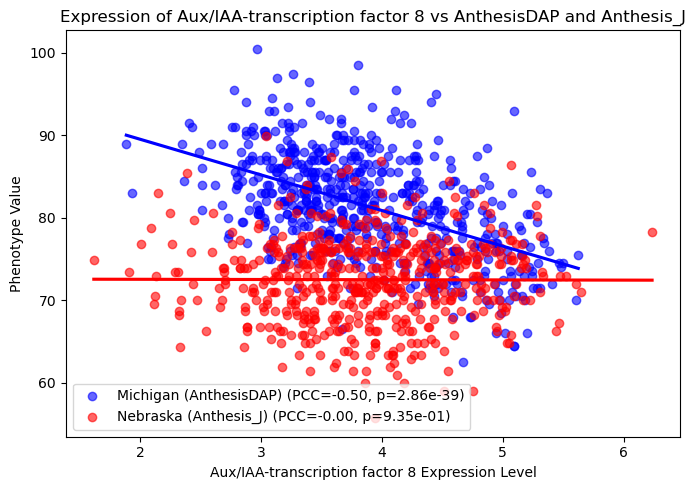

In [13]:
# Example gene + traits
gene = "Zm00001eb122410"
gene2 = "Zm00001eb122410"
trait1 = "AnthesisDAP"     # phenotype for df1
trait2 = "Anthesis_J"     # phenotype for df2

# Extract from two dataframes
x1 = MI_ft_phenos_MI_l2b[gene]
y1 = MI_ft_phenos_MI_l2b[trait1]

x2 = NE_ft_phenos_NE_l2b[gene2]
y2 = NE_ft_phenos_NE_l2b[trait2]

# Calculate PCC for each
pcc1, pval1 = pearsonr(x1, y1)
pcc2, pval2 = pearsonr(x2, y2)

# Plot
plt.figure(figsize=(7, 5))

# First dataset
sns.regplot(x=x1, y=y1, ci=None, 
            line_kws={'color': 'blue'}, scatter_kws={'alpha':0.6, 'color':'blue'}, 
            label=f"Michigan ({trait1}) (PCC={pcc1:.2f}, p={pval1:.2e})")

# Second dataset
sns.regplot(x=x2, y=y2, ci=None, 
            line_kws={'color': 'red'}, scatter_kws={'alpha':0.6, 'color':'red'}, 
            label=f"Nebraska ({trait2}) (PCC={pcc2:.2f}, p={pval2:.2e})")

plt.xlabel(f"Aux/IAA-transcription factor 8 Expression Level")
plt.ylabel("Phenotype Value")
plt.title(f"Expression of Aux/IAA-transcription factor 8 vs {trait1} and {trait2}")
plt.legend()
plt.tight_layout()
#plt.savefig("/Users/madisoncreach/Prediction_Project/Figures/Fig4_D.pdf")


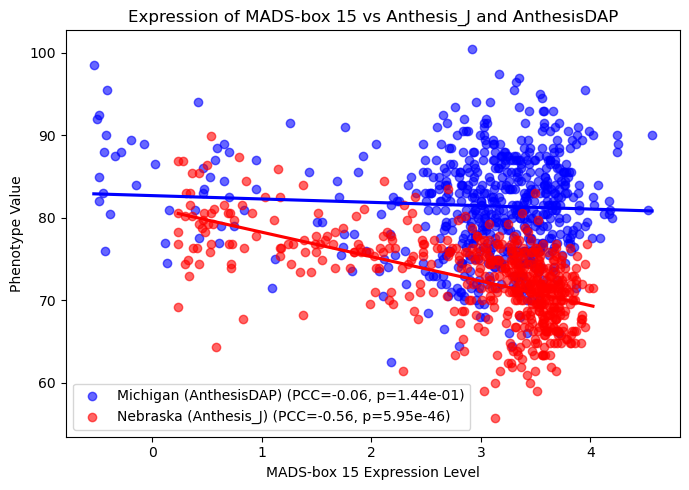

In [14]:
# Example gene + traits
gene = "Zm00001eb214750"
gene2 = "Zm00001eb214750"
trait1 = "AnthesisDAP"     # phenotype for df1
trait2 = "Anthesis_J"     # phenotype for df2

# Extract from two dataframes
x1 = MI_ft_phenos_MI_l2b[gene]
y1 = MI_ft_phenos_MI_l2b[trait1]

x2 = NE_ft_phenos_NE_l2b[gene2]
y2 = NE_ft_phenos_NE_l2b[trait2]

# Calculate PCC for each
pcc1, pval1 = pearsonr(x1, y1)
pcc2, pval2 = pearsonr(x2, y2)

# Plot
plt.figure(figsize=(7, 5))

# First dataset
sns.regplot(x=x1, y=y1, ci=None, 
            line_kws={'color': 'blue'}, scatter_kws={'alpha':0.6, 'color':'blue'}, 
            label=f"Michigan ({trait1}) (PCC={pcc1:.2f}, p={pval1:.2e})")

# Second dataset
sns.regplot(x=x2, y=y2, ci=None, 
            line_kws={'color': 'red'}, scatter_kws={'alpha':0.6, 'color':'red'}, 
            label=f"Nebraska ({trait2}) (PCC={pcc2:.2f}, p={pval2:.2e})")

plt.xlabel(f"MADS-box 15 Expression Level")
plt.ylabel("Phenotype Value")
plt.title(f"Expression of MADS-box 15 vs {trait2} and {trait1}")
plt.legend()
plt.tight_layout()
#plt.savefig("/Users/madisoncreach/Prediction_Project/Figures/Fig4_C.pdf")

In [ ]:
# this is the same loop as above but this now performs cross-fold validation

phenotypes = []
top_shap_features = []
top_weighted_features = []
all_weighted_features = []
r2_scores = {}
pheno_to_do = ["Anthesis_J"]

for i in pheno_to_do:
    pheno_temp = full_phenos[[i]]
    phenotypes.append(i)
    
    # Join and check if join is not empty
    full_phenos_NE_l2b = NE_l2b.join(pheno_temp, how='inner')
    full_phenos_MI_l2b = MI_l2b.join(pheno_temp, how='inner')


    if full_phenos_MI_l2b.empty or full_phenos_NE_l2b.empty:
        print(f"No matching data for phenotype {i}. Skipping.")
        continue
    full_phenos_l2b_NE_MI = pd.concat([full_phenos_NE_l2b, full_phenos_MI_l2b], axis=0).dropna()

    # Define full dataset features (X) and target variable (y)
    X_full = full_phenos_l2b_NE_MI.iloc[:, 1:-2]  # Features (excluding phenotype column)
    y_full = full_phenos_l2b_NE_MI.iloc[:, -1] 

    fold_r2_scores = []

    for fold_num in range(5):  
        
        # Get test sets from both MI and NE
        test_MI = full_phenos_MI_l2b[full_phenos_MI_l2b['fold'] == fold_num]
        test_NE = full_phenos_NE_l2b[full_phenos_NE_l2b['fold'] == fold_num]

        # Train sets: all folds not equal to current fold
        train_MI = full_phenos_MI_l2b[full_phenos_MI_l2b['fold'] != fold_num]
        train_NE = full_phenos_NE_l2b[full_phenos_NE_l2b['fold'] != fold_num]

        # Combine train and test sets
        train = pd.concat([train_MI, train_NE])
        test = pd.concat([test_MI, test_NE])

        # Drop NaNs
        train_final = train.dropna()
        test_final = test.dropna()

        # Split into X and y
        X_train = train_final.iloc[:, 1:-2]
        y_train = train_final.iloc[:, -1]
        X_test = test_final.iloc[:, 1:-2]
        y_test = test_final.iloc[:, -1]

        # Fit and predict
        svm_reg = SVR(kernel='linear')
        svm_reg.fit(X_train, y_train)
        y_pred = svm_reg.predict(X_test)

        plt.figure(figsize=(6, 6))
        plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
        plt.xlabel("Observed")
        plt.ylabel("Predicted")
        plt.title(f"{i} - Full Model")
        plt.tight_layout()
        plt.savefig(f"/Users/madisoncreach/Prediction_Project/Pred_Obs_Plots_T_Final/{i}_FullModel_Pred_vs_Obs.pdf")
        plt.close()

        correlation_coefficient, p_value = pearsonr(y_test, y_pred)
        fold_r2_scores.append(correlation_coefficient)

        #fold_r2_scores.append(r2_score(y_test, y_pred))


    # Store average R² score across all folds
    r2_scores[i] = {
    'mean_r2': np.mean(fold_r2_scores),
    'fold_r2s': fold_r2_scores
    }

    # Train SVR on the full dataset after cross-validation
    svm_reg.fit(X_full, y_full)

    # SHAP analysis using the entire dataset
    explainer = shap.Explainer(svm_reg, X_full)
    shap_values = explainer(X_full)

    # Store SHAP summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_full, feature_names=X_full.columns, show=False)
    plt.title(f'SHAP Summary Plot for {i}')
    plt.close()

    # Store top SHAP features
    mean_shap_values = np.abs(shap_values.values).mean(axis=0)
    top_10000_idx = np.argsort(mean_shap_values)[-10000:]
    top_10000_features = X_full.columns[top_10000_idx]

    top_shap_df = pd.DataFrame({
        'Phenotype': i,
        'Feature': top_10000_features,
        'Mean SHAP Value': mean_shap_values[top_10000_idx]
    })
    top_shap_features.append(top_shap_df)

    # Extract feature weights from SVR coefficients
    feature_weights = svm_reg.coef_.flatten()
    feature_importance_df = pd.DataFrame({
        'Feature': X_full.columns,
        'Weight': feature_weights
    }).sort_values(by='Weight', ascending=False)

    # Store the top 600 features
    top_600_features_df = feature_importance_df.head(600).copy()
    top_600_features_df['Phenotype'] = i
    top_weighted_features.append(top_600_features_df)

    # Store all features
    all_features_df = feature_importance_df.copy()
    all_features_df['Phenotype'] = i
    all_weighted_features.append(all_features_df)

# Combine DataFrames
top_weighted_features_df = pd.concat(top_weighted_features, ignore_index=True)
all_weighted_features_df = pd.concat(all_weighted_features, ignore_index=True)
top_shap_features_df = pd.concat(top_shap_features, ignore_index=True)

In [ ]:
print(fold_r2_scores)

[0.3357904862546083, 0.34579283047103715, 0.27426185198395653, 0.5011511172940404, 0.30088845853229124]


In [ ]:
# convert the r2 dictionary to df
df = pd.DataFrame(list(r2_scores.items()), columns=['Phenotype', 'R2_Score'])

In [ ]:
df['mean_r2'] = df['R2_Score'].apply(lambda x: eval(x)['mean_r2'] if isinstance(x, str) else x['mean_r2'])

In [ ]:
new_df = df[['Phenotype', 'mean_r2']]

In [ ]:
print(new_df)

                Phenotype   mean_r2
0            SilkingGDD_L  0.271801
1           AnthesisGDD_L  0.286159
2                ASIGDD_L  0.200931
3               Silking_L  0.767761
4             Anthesis1_L  0.790077
..                    ...       ...
124  LargestLeafLengthAvg  0.554606
125           AnthesisDAP  0.702398
126            SilkingDAP  0.671042
127         dry_g_per_ear  0.497087
128      TestWeight.lb.bu  0.351577

[129 rows x 2 columns]


In [ ]:
#new_df.to_csv('/Users/madisoncreach/Prediction_Project/svr_pcc_scores_transcriptomic.csv', index=False)

In [ ]:
#all_weighted_features_df.to_csv("/Users/madisoncreach/Prediction_Project/SVR_weighted_features_exp.csv")